# Nielsen Beverage Retail — EDA Report
**Market:** Pacific Division xAOC &nbsp;|&nbsp; **Period:** Jan 2025 – Feb 2026 &nbsp;|&nbsp; **Scope:** 6 beverage categories, 377 brands, 3 769 UPCs

---

In [1]:
import glob, os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, '/tmp/openpyxl_pkg')
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110})

CAT_COLORS = {
    'WATER': '#4C72B0',
    'VALUE ADD WATER': '#55A868',
    'SPORT DRINKS': '#C44E52',
    'HEALTH/NUTRITION SHAKES': '#8172B3',
    'PERFORMANCE NUTRITION SHAKES': '#CCB974',
    'MEAL REPLACEMENT SHAKES': '#64B5CD',
}

files = sorted(glob.glob('../data/bquxjob*.csv'))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df['week_ending'] = pd.to_datetime(df['week_ending'])

dd = pd.read_excel(
    '../data/Nielsen_Data_Dictionary.xlsx', sheet_name='Data Dictionary',
    usecols=['variable_name','description','data_type','variable_category','sample_null_pct']
)
dd['null_pct'] = (dd['sample_null_pct'] * 100).round(1)

cat_sales = (
    df.dropna(subset=['category'])
    .groupby('category')['sales'].sum()
    .sort_values(ascending=False)
)
cat_order = cat_sales.index.tolist()
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {len(files)} files.')


Loaded 162,965 rows x 82 columns from 19 files.


---
## 1. Dataset Overview

In [2]:
overview = pd.DataFrame({
    'Metric': [
        'Total rows','Total columns','Source CSV files',
        'Date range','Unique weeks','Years',
        'Unique UPCs','Unique brands','Unique items',
        'Market','Geography hierarchy',
    ],
    'Value': [
        f'{df.shape[0]:,}', df.shape[1], len(files),
        f"{df['week_ending'].min().date()} to {df['week_ending'].max().date()}",
        df['week_ending'].nunique(),
        ', '.join(str(y) for y in sorted(df['year'].unique())),
        f"{df['upc'].nunique():,}",
        f"{df['brand'].nunique():,}",
        f"{df['item'].nunique():,}",
        df['markets'].iloc[0],
        f"{df['l1'].iloc[0]} / {df['l2'].iloc[0]}",
    ]
})
display(overview.style.hide(axis='index').set_properties(**{'text-align': 'left'}))


Metric,Value
Total rows,"162,965"
Total columns,82
Source CSV files,19
Date range,2025-01-04 to 2026-02-21
Unique weeks,60
Years,"2025, 2026"
Unique UPCs,"3,769"
Unique brands,377
Unique items,"3,468"
Market,Pacific Division xAOC


---
## 2. Data Quality

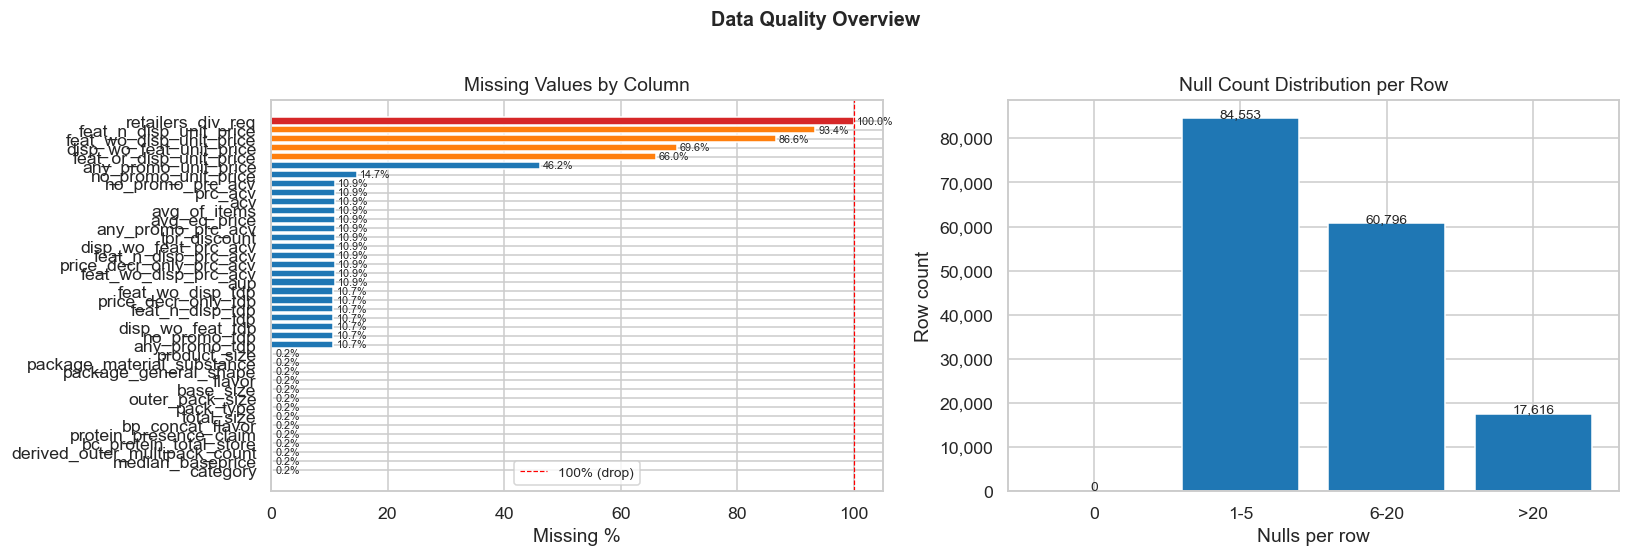

Duplicate rows: 0
retailers_div_req: 100% null — safe to drop
acv == prc_acv always: True (redundant)


In [3]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'null_count': nulls, 'null_pct': null_pct})
null_df = null_df[null_df.null_count > 0].sort_values('null_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#d62728' if p == 100 else '#ff7f0e' if p > 50 else '#1f77b4'
          for p in null_df['null_pct']]
axes[0].barh(null_df.index, null_df['null_pct'], color=colors)
axes[0].axvline(100, color='red', linestyle='--', linewidth=0.8, label='100% (drop)')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values by Column')
axes[0].legend(fontsize=9)
for i, v in enumerate(null_df['null_pct']):
    axes[0].text(v + 0.5, i, f'{v}%', va='center', fontsize=7)

null_per_row = df.isnull().sum(axis=1)
labels = ['0', '1-5', '6-20', '>20']
counts_vals = [
    (null_per_row == 0).sum(),
    ((null_per_row >= 1) & (null_per_row <= 5)).sum(),
    ((null_per_row >= 6) & (null_per_row <= 20)).sum(),
    (null_per_row > 20).sum(),
]
axes[1].bar(labels, counts_vals, color='#1f77b4', edgecolor='white')
axes[1].set_xlabel('Nulls per row')
axes[1].set_ylabel('Row count')
axes[1].set_title('Null Count Distribution per Row')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate(counts_vals):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Data Quality Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Duplicate rows: {df.duplicated().sum():,}")
print("retailers_div_req: 100% null — safe to drop")
print(f"acv == prc_acv always: {(df['acv'] == df['prc_acv']).sum() == df['acv'].notna().sum()} (redundant)")


---
## 3. Category Overview

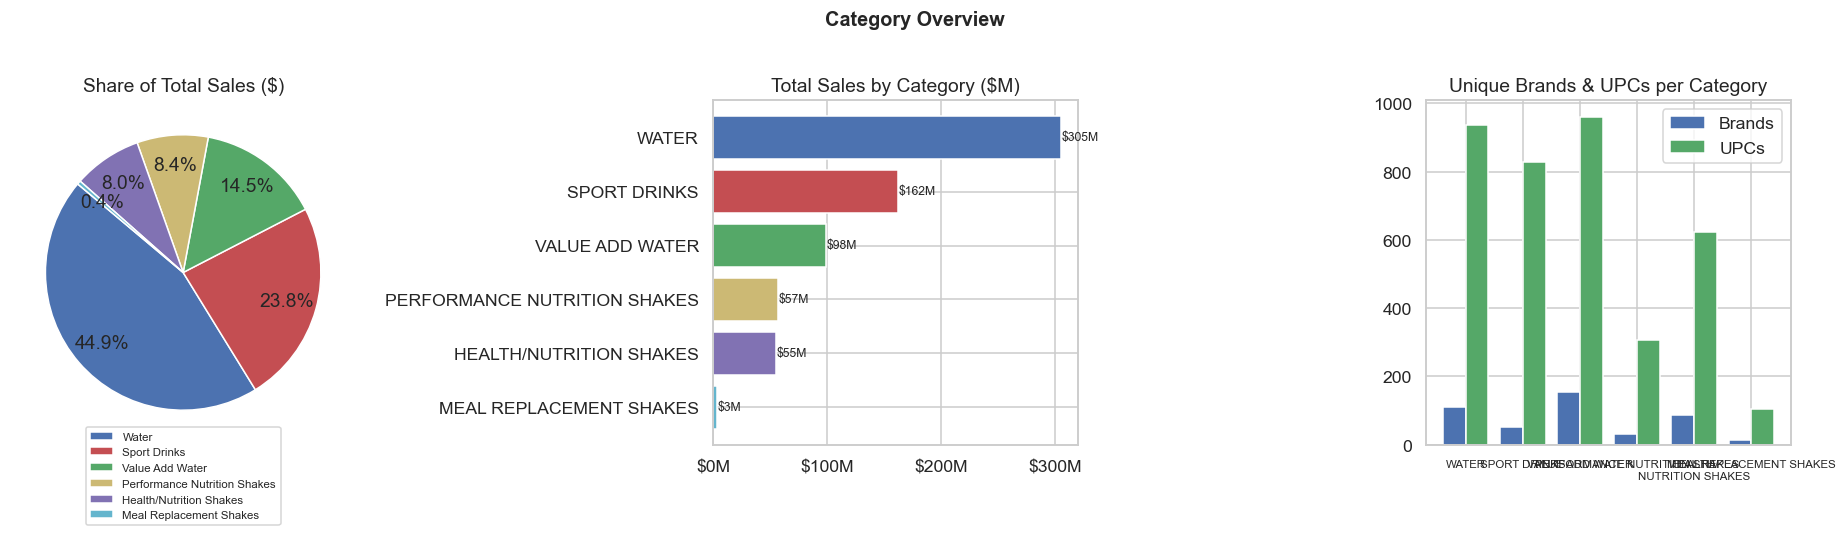

,total_sales,total_units,unique_brands,unique_upcs,n_rows
category,,,,,
WATER,"$305,274,900","94,737,252",110,937,41983
SPORT DRINKS,"$161,841,506","51,192,410",52,828,35650
VALUE ADD WATER,"$98,451,629","30,468,963",153,961,40338
PERFORMANCE NUTRITION SHAKES,"$56,796,373","8,084,441",31,306,12764
HEALTH/NUTRITION SHAKES,"$54,580,336","5,294,193",86,622,27925
MEAL REPLACEMENT SHAKES,"$2,955,825","273,119",14,105,3988


In [4]:
cat_agg = (
    df.dropna(subset=['category'])
    .groupby('category').agg(
        total_sales=('sales','sum'),
        total_units=('units','sum'),
        unique_brands=('brand','nunique'),
        unique_upcs=('upc','nunique'),
        n_rows=('sales','count'),
    ).loc[cat_order]
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = [CAT_COLORS.get(c, '#999') for c in cat_order]
wedges, _, autotexts = axes[0].pie(
    cat_agg['total_sales'], autopct='%1.1f%%',
    colors=colors, startangle=140, pctdistance=0.78, labels=None
)
axes[0].legend(wedges, [c.title() for c in cat_order],
               loc='lower center', bbox_to_anchor=(0.5, -0.25), fontsize=7.5, ncol=1)
axes[0].set_title('Share of Total Sales ($)')

bars = axes[1].barh(cat_order[::-1], cat_agg['total_sales'][::-1]/1e6, color=colors[::-1])
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
axes[1].set_title('Total Sales by Category ($M)')
for bar, val in zip(bars, cat_agg['total_sales'][::-1]):
    axes[1].text(val/1e6 + 0.5, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.0f}M', va='center', fontsize=8)

x = np.arange(len(cat_order))
w = 0.4
axes[2].bar(x - w/2, cat_agg['unique_brands'], w, label='Brands', color='#4C72B0')
axes[2].bar(x + w/2, cat_agg['unique_upcs'], w, label='UPCs', color='#55A868')
axes[2].set_xticks(x)
axes[2].set_xticklabels([c.replace('/', '/\n') for c in cat_order], fontsize=7.5)
axes[2].set_title('Unique Brands & UPCs per Category')
axes[2].legend()

plt.suptitle('Category Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

display(cat_agg.style
    .format({'total_sales': '${:,.0f}', 'total_units': '{:,.0f}'})
    .bar(subset=['total_sales'], color='#4C72B0'))


---
## 4. Weekly Sales Trend

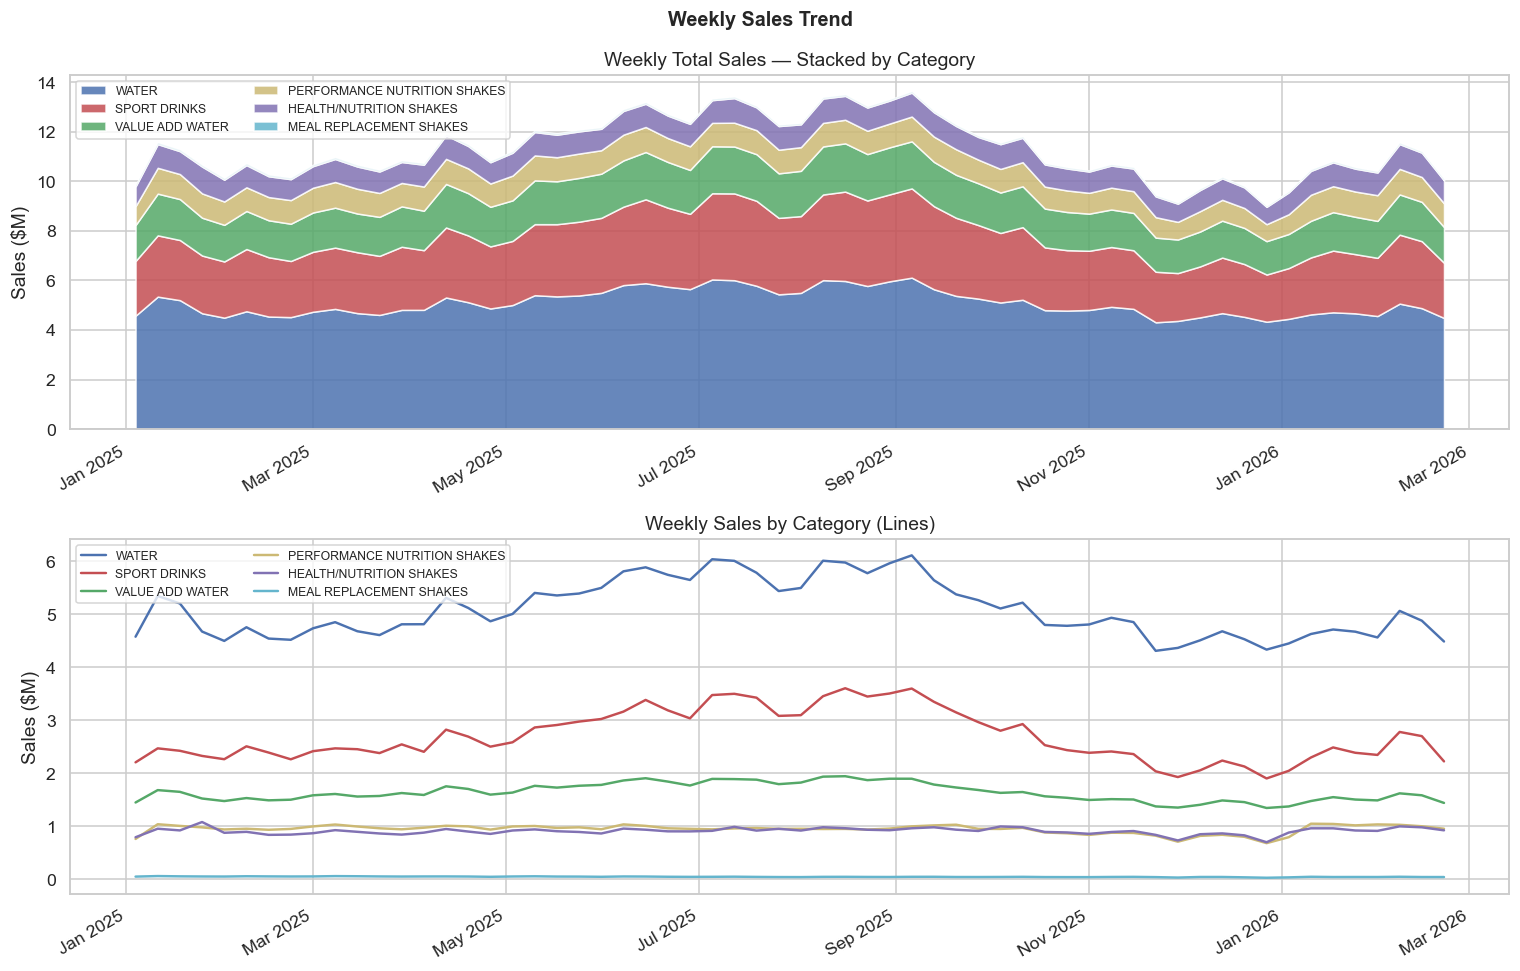

In [5]:
weekly = (
    df.dropna(subset=['category'])
    .groupby(['week_ending','category'])['sales']
    .sum().unstack(fill_value=0)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].stackplot(
    weekly.index,
    [weekly.get(c, pd.Series(0, index=weekly.index))/1e6 for c in cat_order],
    labels=cat_order,
    colors=[CAT_COLORS.get(c,'#999') for c in cat_order],
    alpha=0.85
)
axes[0].set_ylabel('Sales ($M)')
axes[0].set_title('Weekly Total Sales — Stacked by Category')
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

for cat in cat_order:
    if cat in weekly.columns:
        axes[1].plot(weekly.index, weekly[cat]/1e6, label=cat,
                     color=CAT_COLORS.get(cat,'#999'), linewidth=1.6)
axes[1].set_ylabel('Sales ($M)')
axes[1].set_title('Weekly Sales by Category (Lines)')
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Weekly Sales Trend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5. Brand Analysis

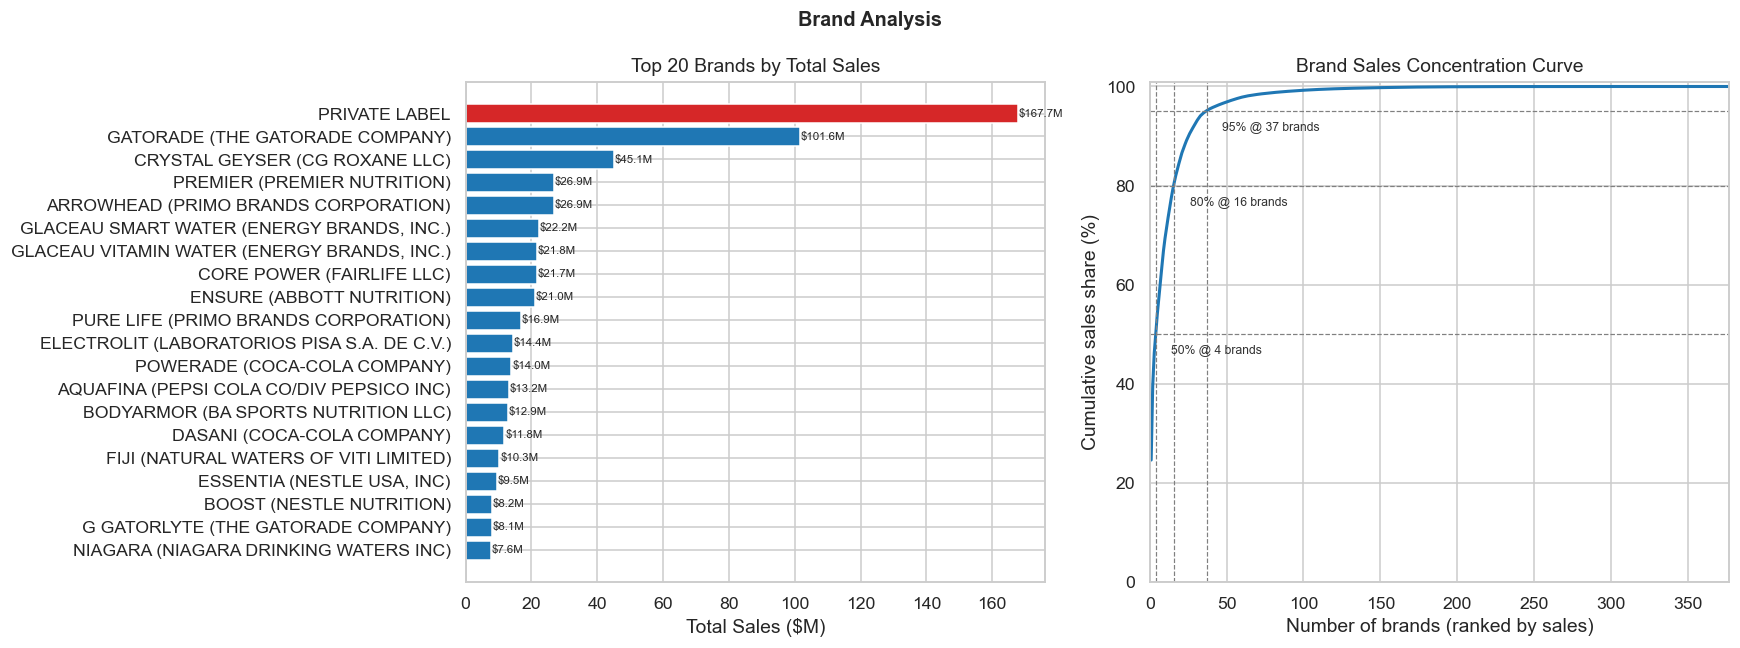

In [6]:
brand_sales = df.groupby('brand')['sales'].sum().sort_values(ascending=False)
top20 = brand_sales.head(20)
total_s = brand_sales.sum()
cumshare = (brand_sales / total_s).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_20 = ['#d62728' if b == 'PRIVATE LABEL' else '#1f77b4' for b in top20.index]
axes[0].barh(top20.index[::-1], top20.values[::-1]/1e6, color=colors_20[::-1])
axes[0].set_xlabel('Total Sales ($M)')
axes[0].set_title('Top 20 Brands by Total Sales')
for i, v in enumerate(top20.values[::-1]):
    axes[0].text(v/1e6 + 0.2, i, f'${v/1e6:.1f}M', va='center', fontsize=7.5)

axes[1].plot(range(1, len(brand_sales)+1), cumshare.values * 100, color='#1f77b4', linewidth=2)
for pct, label in [(0.5,'50%'), (0.8,'80%'), (0.95,'95%')]:
    n = (cumshare < pct).sum() + 1
    axes[1].axhline(pct*100, color='grey', linestyle='--', linewidth=0.8)
    axes[1].axvline(n, color='grey', linestyle='--', linewidth=0.8)
    axes[1].annotate(f'{label} @ {n} brands', xy=(n, pct*100),
                     xytext=(n+10, pct*100-4), fontsize=8, color='#333')
axes[1].set_xlabel('Number of brands (ranked by sales)')
axes[1].set_ylabel('Cumulative sales share (%)')
axes[1].set_title('Brand Sales Concentration Curve')
axes[1].set_xlim(0, len(brand_sales))
axes[1].set_ylim(0, 101)

plt.suptitle('Brand Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Pricing Analysis

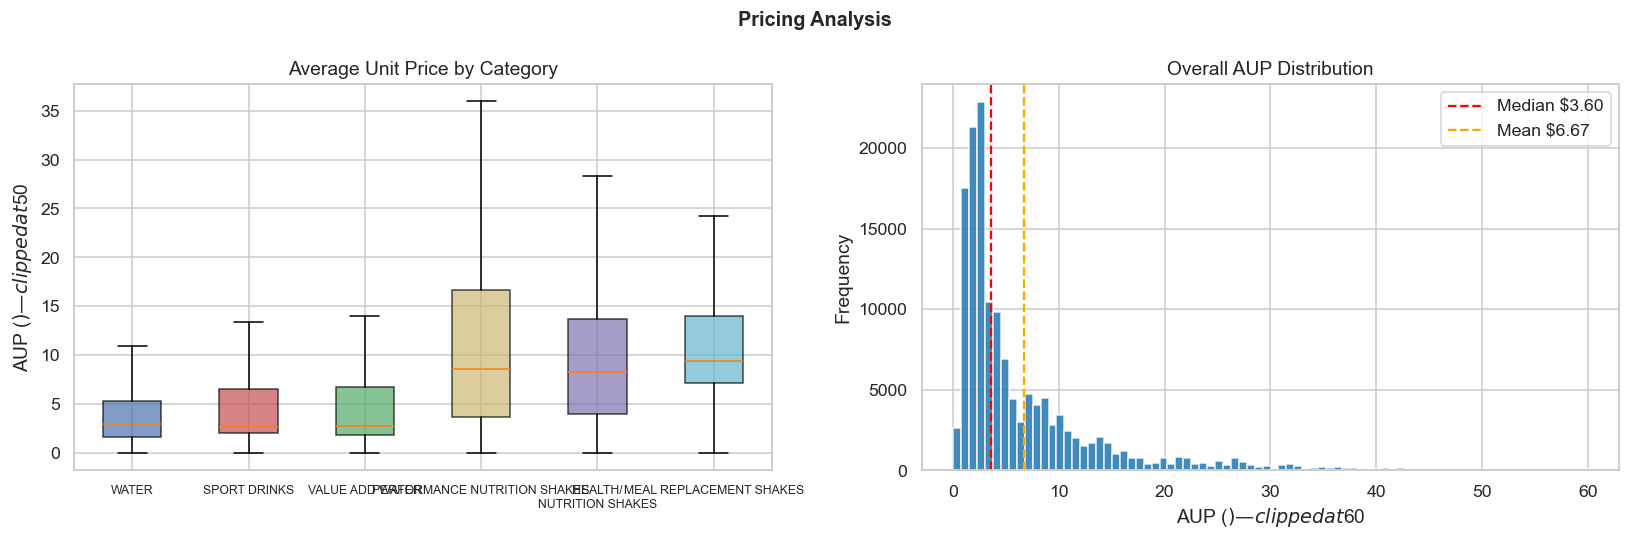

AUP descriptive stats by category:


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
HEALTH/NUTRITION SHAKES,25592.0,10.97,9.70,0.00,3.99,8.31,13.73,98.37
MEAL REPLACEMENT SHAKES,3317.0,10.70,6.16,0.01,7.14,9.40,13.98,44.99
PERFORMANCE NUTRITION SHAKES,11258.0,12.27,11.97,0.01,3.66,8.57,16.66,68.97
SPORT DRINKS,31899.0,4.59,4.39,0.00,1.99,2.62,6.54,53.99
VALUE ADD WATER,35787.0,5.32,5.79,0.00,1.86,2.73,6.72,61.30
WATER,37300.0,4.76,6.06,0.00,1.59,2.98,5.32,160.73


In [7]:
price_df = df.dropna(subset=['category','aup'])
price_df = price_df[price_df['aup'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

data_by_cat = [price_df[price_df['category']==c]['aup'].clip(upper=50) for c in cat_order]
bp = axes[0].boxplot(data_by_cat, patch_artist=True, showfliers=False)
for patch, cat in zip(bp['boxes'], cat_order):
    patch.set_facecolor(CAT_COLORS.get(cat,'#999'))
    patch.set_alpha(0.7)
axes[0].set_xticks(range(1, len(cat_order)+1))
axes[0].set_xticklabels([c.replace('/','/\n') for c in cat_order], fontsize=8)
axes[0].set_ylabel('AUP ($) — clipped at $50')
axes[0].set_title('Average Unit Price by Category')

axes[1].hist(price_df['aup'].clip(upper=60), bins=80, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[1].axvline(price_df['aup'].median(), color='red', linestyle='--',
                label=f"Median ${price_df['aup'].median():.2f}")
axes[1].axvline(price_df['aup'].mean(), color='orange', linestyle='--',
                label=f"Mean ${price_df['aup'].mean():.2f}")
axes[1].set_xlabel('AUP ($) — clipped at $60')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Overall AUP Distribution')
axes[1].legend()

plt.suptitle('Pricing Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("AUP descriptive stats by category:")
display(df.groupby('category')['aup'].describe().round(2))


---
## 7. Promotions

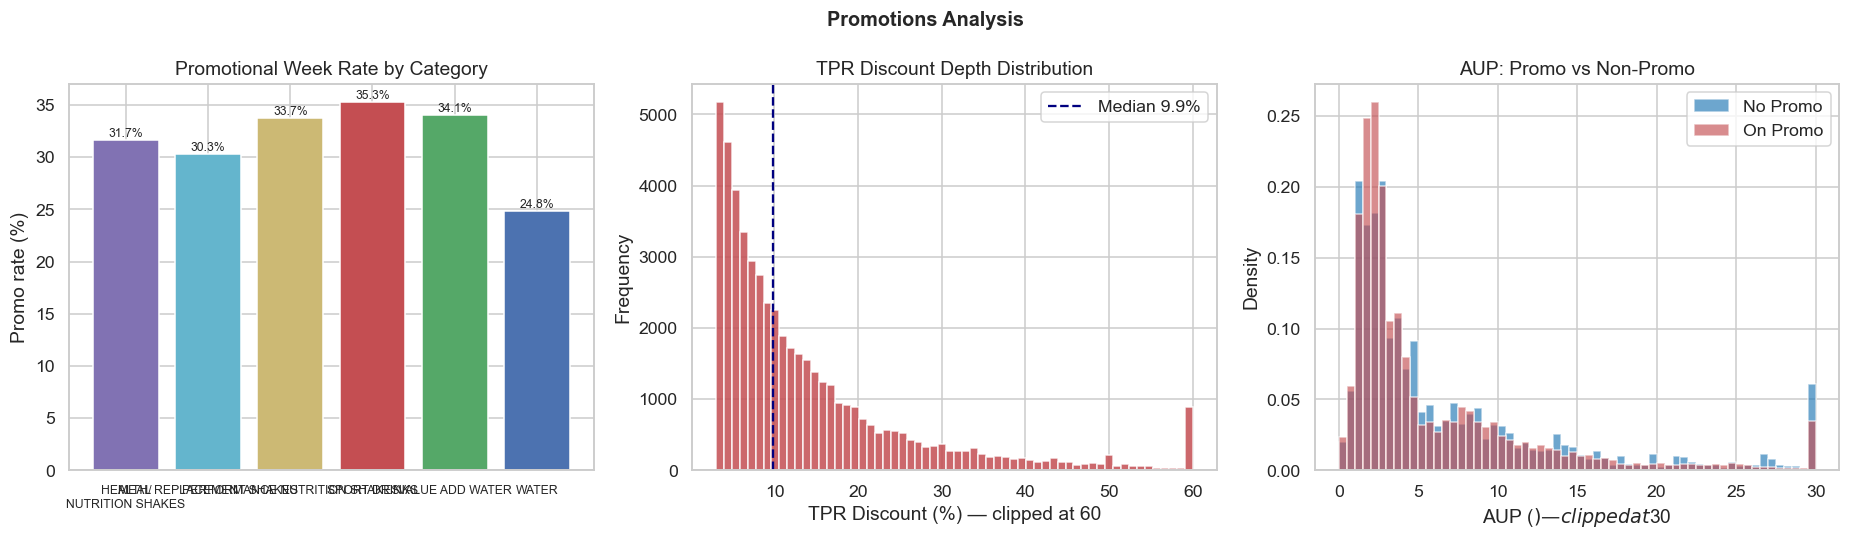

In [8]:
promo = df.dropna(subset=['category'])
promo_rate = promo.groupby('category')['promo_flag'].mean() * 100
tpr_df = promo[promo['tpr_discount'] > 0].dropna(subset=['tpr_discount'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

bars = axes[0].bar(promo_rate.index, promo_rate.values,
                   color=[CAT_COLORS.get(c,'#999') for c in promo_rate.index])
axes[0].set_ylabel('Promo rate (%)')
axes[0].set_title('Promotional Week Rate by Category')
axes[0].set_xticklabels([c.replace('/','/\n') for c in promo_rate.index], fontsize=8)
for bar, val in zip(bars, promo_rate.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)

axes[1].hist(tpr_df['tpr_discount'].clip(upper=60), bins=60,
             color='#C44E52', edgecolor='white', alpha=0.85)
axes[1].axvline(tpr_df['tpr_discount'].median(), color='navy', linestyle='--',
                label=f"Median {tpr_df['tpr_discount'].median():.1f}%")
axes[1].set_xlabel('TPR Discount (%) — clipped at 60')
axes[1].set_ylabel('Frequency')
axes[1].set_title('TPR Discount Depth Distribution')
axes[1].legend()

promo_aup = promo[promo['promo_flag']==1]['aup'].dropna()
nonpromo_aup = promo[promo['promo_flag']==0]['aup'].dropna()
axes[2].hist(nonpromo_aup.clip(upper=30), bins=60, alpha=0.65,
             color='#1f77b4', edgecolor='white', label='No Promo', density=True)
axes[2].hist(promo_aup.clip(upper=30), bins=60, alpha=0.65,
             color='#C44E52', edgecolor='white', label='On Promo', density=True)
axes[2].set_xlabel('AUP ($) — clipped at $30')
axes[2].set_ylabel('Density')
axes[2].set_title('AUP: Promo vs Non-Promo')
axes[2].legend()

plt.suptitle('Promotions Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8. Distribution Metrics (% ACV / TDP)

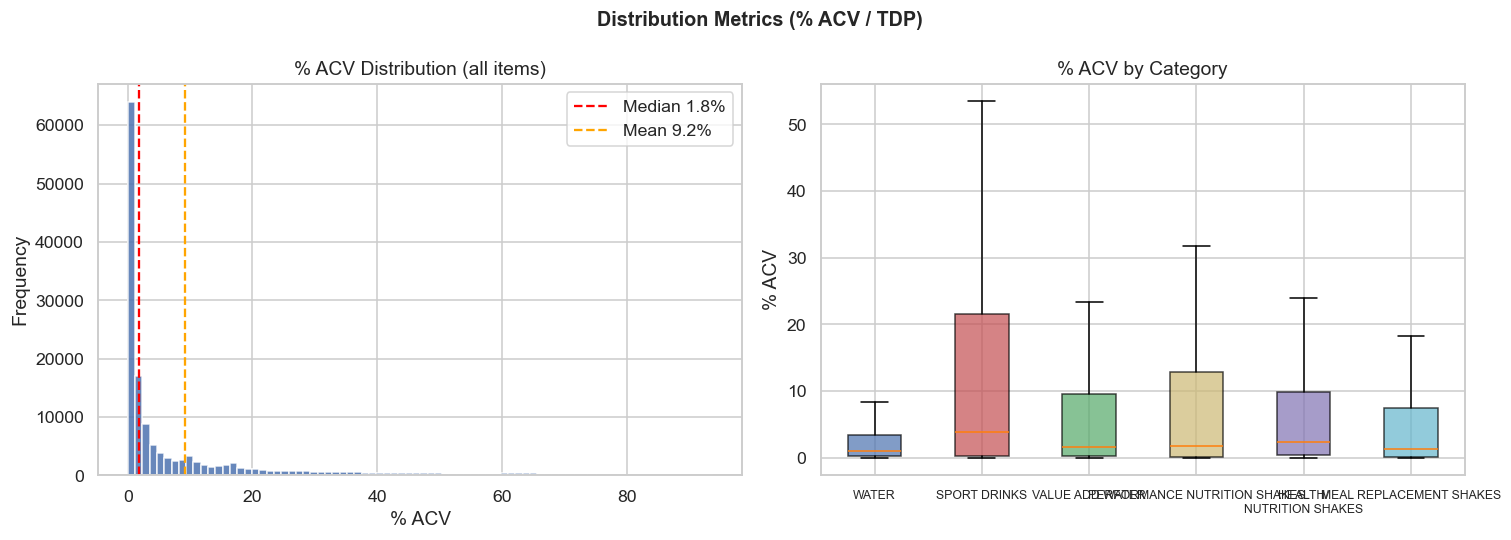

In [9]:
dist_df = df.dropna(subset=['prc_acv','category'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dist_df['prc_acv'].clip(upper=95), bins=80,
             color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(dist_df['prc_acv'].median(), color='red', linestyle='--',
                label=f"Median {dist_df['prc_acv'].median():.1f}%")
axes[0].axvline(dist_df['prc_acv'].mean(), color='orange', linestyle='--',
                label=f"Mean {dist_df['prc_acv'].mean():.1f}%")
axes[0].set_xlabel('% ACV')
axes[0].set_ylabel('Frequency')
axes[0].set_title('% ACV Distribution (all items)')
axes[0].legend()

data_acv = [dist_df[dist_df['category']==c]['prc_acv'] for c in cat_order]
bp2 = axes[1].boxplot(data_acv, patch_artist=True, showfliers=False)
for patch, cat in zip(bp2['boxes'], cat_order):
    patch.set_facecolor(CAT_COLORS.get(cat,'#999'))
    patch.set_alpha(0.7)
axes[1].set_xticks(range(1, len(cat_order)+1))
axes[1].set_xticklabels([c.replace('/','/\n') for c in cat_order], fontsize=8)
axes[1].set_ylabel('% ACV')
axes[1].set_title('% ACV by Category')

plt.suptitle('Distribution Metrics (% ACV / TDP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9. Pack Type & Packaging

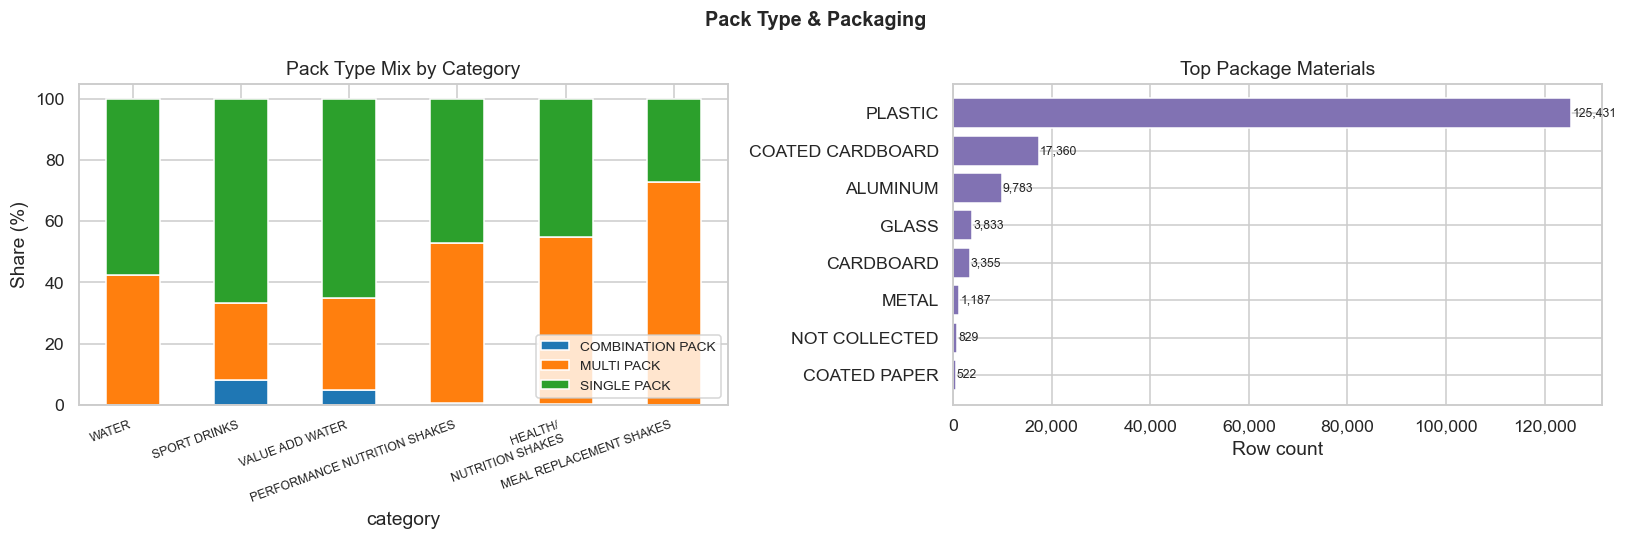

In [10]:
pack_ct = df.dropna(subset=['category','pack_type'])
pack_pivot = pack_ct.groupby(['category','pack_type']).size().unstack(fill_value=0)
pack_pct = pack_pivot.div(pack_pivot.sum(axis=1), axis=0) * 100
mat_ct = df['package_material_substance'].value_counts(dropna=True).head(8)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

valid_cats = [c for c in cat_order if c in pack_pct.index]
pack_pct.loc[valid_cats].plot(kind='bar', stacked=True, ax=axes[0],
    color=['#1f77b4','#ff7f0e','#2ca02c'], edgecolor='white')
axes[0].set_xticklabels([c.replace('/','/\n') for c in valid_cats],
                         rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Share (%)')
axes[0].set_title('Pack Type Mix by Category')
axes[0].legend(loc='lower right', fontsize=9)

axes[1].barh(mat_ct.index[::-1], mat_ct.values[::-1], color='#8172B3')
axes[1].set_xlabel('Row count')
axes[1].set_title('Top Package Materials')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for i, v in enumerate(mat_ct.values[::-1]):
    axes[1].text(v+200, i, f'{v:,}', va='center', fontsize=8)

plt.suptitle('Pack Type & Packaging', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 10. Seasonality & Holidays

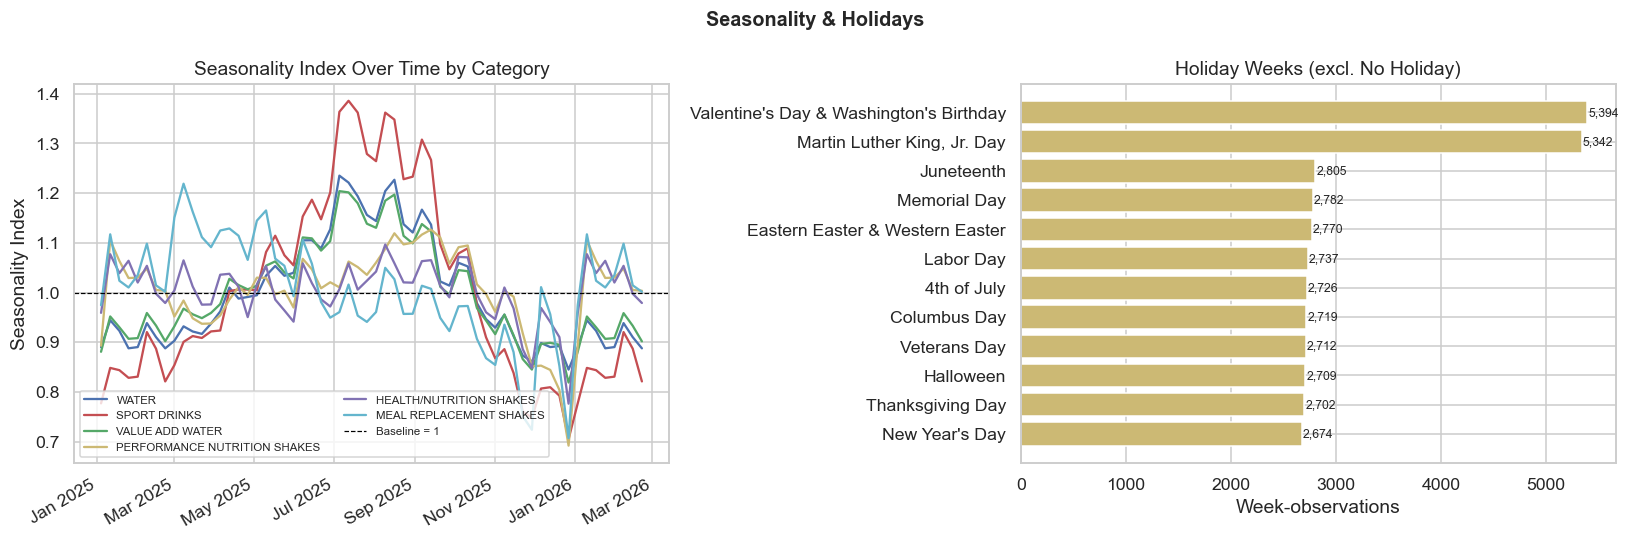

In [11]:
seas_weekly = (
    df.dropna(subset=['category'])
    .groupby(['week_ending','category'])['seasonality_index']
    .mean().unstack()
)
hol = df['Holiday'].value_counts()
hol_clean = hol[hol.index != 'No Holiday'].head(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for cat in cat_order:
    if cat in seas_weekly.columns:
        axes[0].plot(seas_weekly.index, seas_weekly[cat],
                     label=cat, color=CAT_COLORS.get(cat,'#999'), linewidth=1.5)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='Baseline = 1')
axes[0].set_ylabel('Seasonality Index')
axes[0].set_title('Seasonality Index Over Time by Category')
axes[0].legend(fontsize=7.5, ncol=2)
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[1].barh(hol_clean.index[::-1], hol_clean.values[::-1], color='#CCB974')
axes[1].set_xlabel('Week-observations')
axes[1].set_title('Holiday Weeks (excl. No Holiday)')
for i, v in enumerate(hol_clean.values[::-1]):
    axes[1].text(v+10, i, f'{v:,}', va='center', fontsize=8)

plt.suptitle('Seasonality & Holidays', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 11. Correlation Matrix

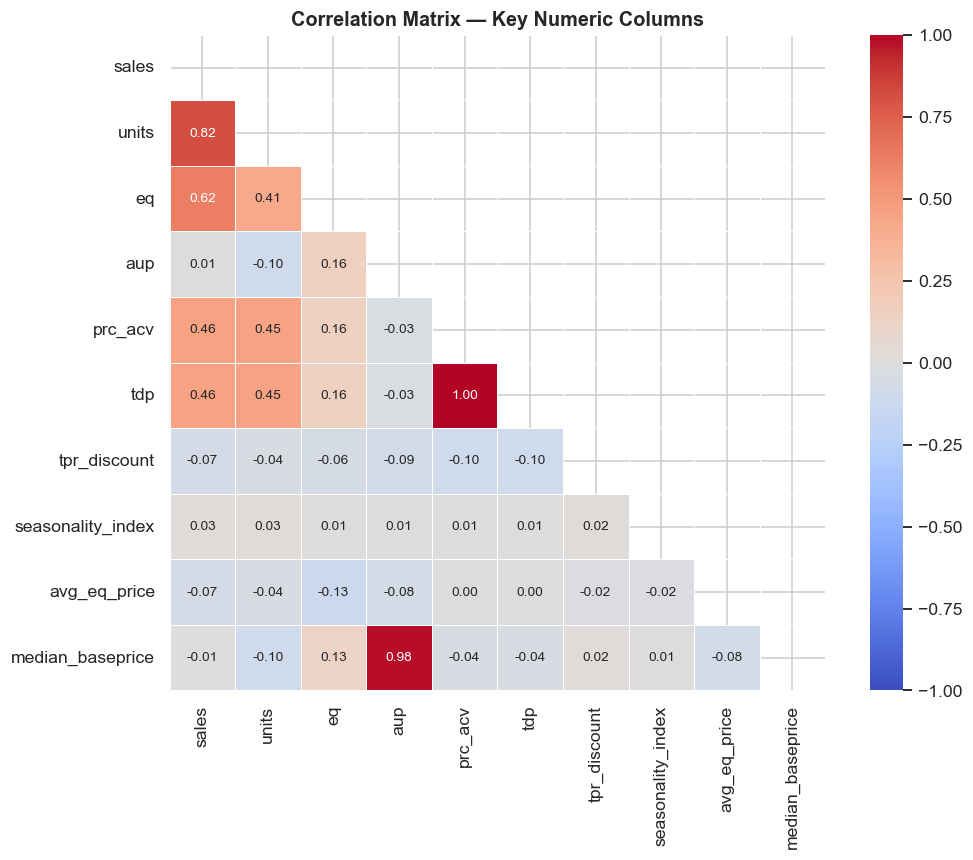

In [12]:
key_cols = ['sales','units','eq','aup','prc_acv','tdp',
            'tpr_discount','seasonality_index','avg_eq_price','median_baseprice']
corr = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Key Numeric Columns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 12. Sales & Units Distributions

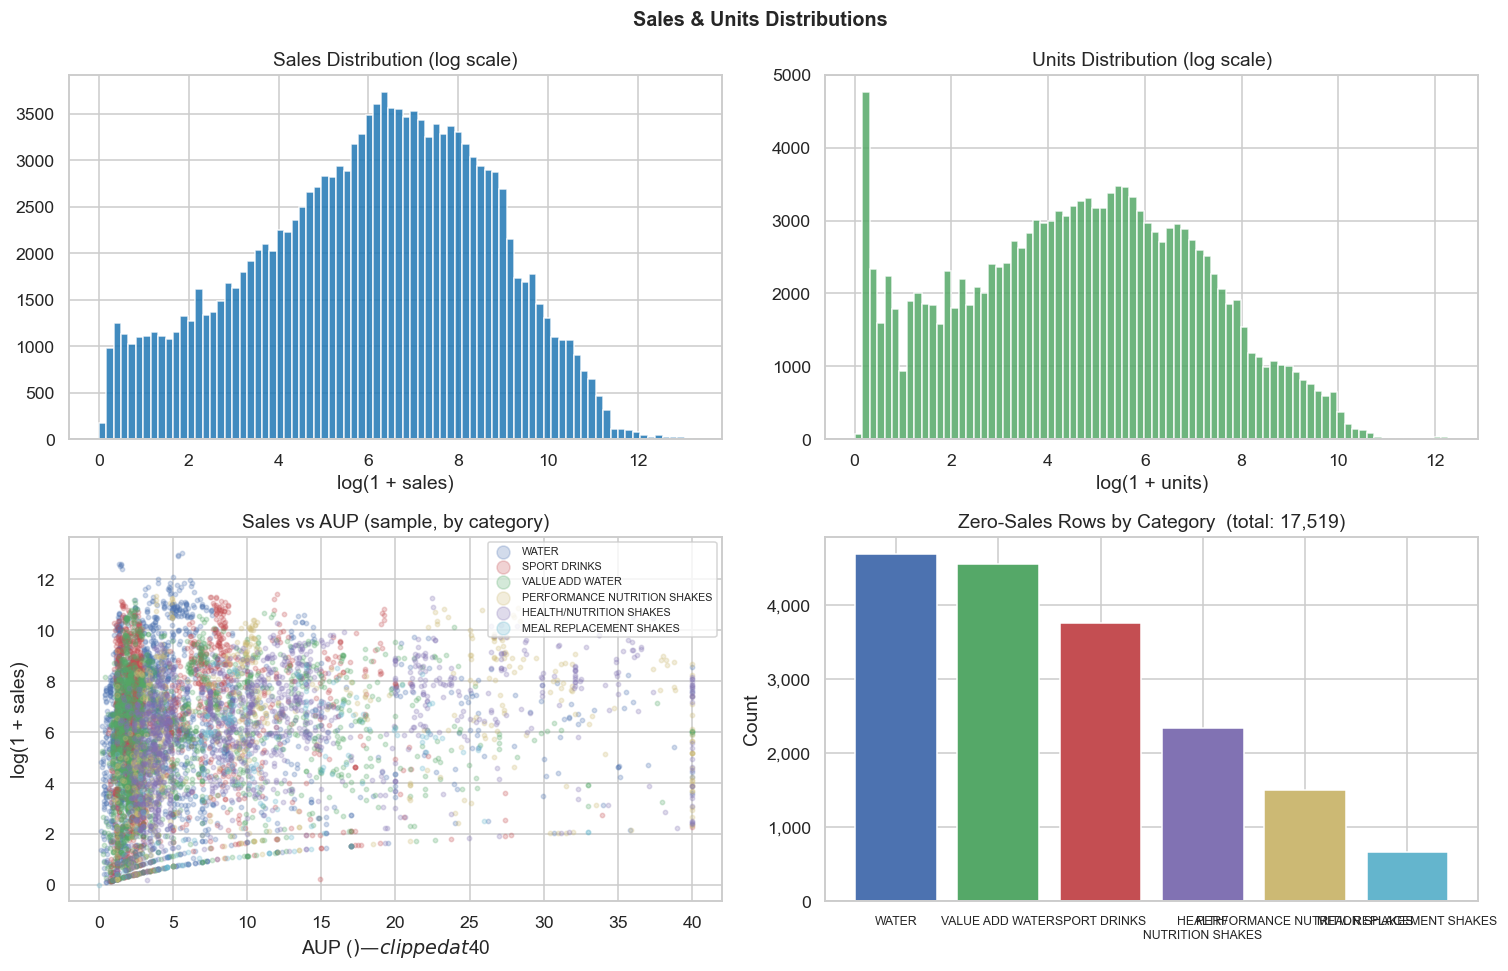

In [13]:
pos = df[(df['sales'] > 0) & (df['units'] > 0)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].hist(np.log1p(pos['sales']), bins=80, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0,0].set_xlabel('log(1 + sales)')
axes[0,0].set_title('Sales Distribution (log scale)')

axes[0,1].hist(np.log1p(pos['units']), bins=80, color='#55A868', edgecolor='white', alpha=0.85)
axes[0,1].set_xlabel('log(1 + units)')
axes[0,1].set_title('Units Distribution (log scale)')

sample = pos.dropna(subset=['aup','category']).sample(min(8000, len(pos)), random_state=42)
for cat in cat_order:
    s = sample[sample['category']==cat]
    if not s.empty:
        axes[1,0].scatter(s['aup'].clip(upper=40), np.log1p(s['sales']),
                          alpha=0.25, s=8, color=CAT_COLORS.get(cat,'#999'), label=cat)
axes[1,0].set_xlabel('AUP ($) — clipped at $40')
axes[1,0].set_ylabel('log(1 + sales)')
axes[1,0].set_title('Sales vs AUP (sample, by category)')
axes[1,0].legend(fontsize=7, markerscale=3)

zero = df[df['sales']==0].dropna(subset=['category'])
zero_by_cat = zero['category'].value_counts()
axes[1,1].bar(zero_by_cat.index, zero_by_cat.values,
              color=[CAT_COLORS.get(c,'#999') for c in zero_by_cat.index])
axes[1,1].set_xticklabels([c.replace('/','/\n') for c in zero_by_cat.index], fontsize=8)
axes[1,1].set_ylabel('Count')
axes[1,1].set_title(f'Zero-Sales Rows by Category  (total: {len(zero):,})')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Sales & Units Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 13. Key Findings

In [14]:
brand_sales = df.groupby('brand')['sales'].sum().sort_values(ascending=False)
cumshare2 = (brand_sales / brand_sales.sum()).cumsum()
n80 = (cumshare2 < 0.8).sum() + 1
promo_overall = df['promo_flag'].mean() * 100
zero_pct = (df['sales'] == 0).mean() * 100
water_share = df[df['category']=='WATER']['sales'].sum() / df['sales'].sum() * 100

findings = pd.DataFrame({
    'Finding': [
        'Total $ sales in dataset',
        'Largest category — Water',
        'Top 5 brands share of sales',
        'Brands needed for 80% of sales',
        'Overall promotional week rate',
        'Zero-sales rows',
        'Fully null column',
        'Redundant column',
        'Peak sales season',
        'Sparsest promo price columns',
        'Modeling recommendation',
    ],
    'Value / Observation': [
        f"${df['sales'].sum()/1e6:.0f}M",
        f'{water_share:.1f}% of total sales',
        f"{(brand_sales.head(5).sum()/brand_sales.sum()*100):.1f}%",
        f'{n80} out of {len(brand_sales)} brands',
        f'{promo_overall:.1f}% of rows',
        f'{zero_pct:.1f}% — mostly non-promo (listing without velocity)',
        'retailers_div_req — 100% null, drop',
        'acv == prc_acv always — drop one',
        'Jun–Sep (Sport Drinks & Water +50-60% vs Jan baseline)',
        'feat_n_disp_unit_price 93% null; feat_wo_disp 87% null',
        'Log-transform sales/units; model per category; use prc_acv not acv',
    ]
})
display(findings.style.hide(axis='index').set_properties(**{'text-align':'left'}))


Finding,Value / Observation
Total $ sales in dataset,$680M
Largest category — Water,44.9% of total sales
Top 5 brands share of sales,54.2%
Brands needed for 80% of sales,16 out of 377 brands
Overall promotional week rate,31.4% of rows
Zero-sales rows,10.9% — mostly non-promo (listing without velocity)
Fully null column,"retailers_div_req — 100% null, drop"
Redundant column,acv == prc_acv always — drop one
Peak sales season,Jun–Sep (Sport Drinks & Water +50-60% vs Jan baseline)
Sparsest promo price columns,feat_n_disp_unit_price 93% null; feat_wo_disp 87% null
